# Problem Set 2

## Introduction to the assignment

For this assignment, you will be using data from the [Progresa program](http://en.wikipedia.org/wiki/Oportunidades), a government social assistance program in Mexico. This program, as well as the details of its impact, are described in the paper "[School subsidies for the poor: evaluating the Mexican Progresa poverty program](http://www.sciencedirect.com/science/article/pii/S0304387803001858)", by Paul Shultz (available on bCourses). Please familiarize yourself with the PROGRESA program before beginning this problem set, so you have a rough sense of where the data come from and how they were generated. If you just proceed into the problem set without understanding Progresa or the data, it will be very difficult!

The goal of this problem set is to implement some of the basic econometric techniques that you are learning in class to measure the impact of Progresa on secondary school enrollment rates. The timeline of the program was:

 * Baseline survey conducted in 1997
 * Intervention begins in 1998, "Wave 1" of surveys conducted in 1998
 * "Wave 2" of surveys conducted in 1999
 * Evaluation ends in 2000, at which point the control villages were treated. 
 
When you are ready, download the progresa_sample.csv data from bCourses. The data are actual data collected to evaluate the impact of the Progresa program.  In this file, each row corresponds to an observation taken for a given child for a given year. There are two years of data (1997 and 1998), and just under 40,000 children who are surveyed in each year. For each child-year observation, the following variables are collected:

| Variable name | Description|
|------|------|
|year	  |year in which data is collected
|sex	  |male = 1|
|indig	  |indigenous = 1|
|dist_sec |nearest distance to a secondary school|
|sc	      |enrolled in school in year of survey|
|grc      |grade enrolled|
|fam_n    |family size|
|min_dist |	min distance to an urban center|
|dist_cap |	min distance to the capital|
|poor     |	poor = 1|
|progresa |treatment =1|
|hohedu	  |years of schooling of head of household|
|hohwag	  |monthly wages of head of household|
|welfare_index|	welfare index used to classify poor|
|hohsex	|gender of head of household (male=1)|
|hohage	|age of head of household|
|age	|years old|
|folnum	|individual id|
|village|	village id|
|sc97	|schooling in 1997|
|grc97  |grade enrolled in 1997

---

## Part 1: Descriptive analysis

### 1.1	Summary Statistics

Present summary statistics (mean, median and standard deviation) for all of the demographic variables in the dataset (i.e., everything except year, folnum, village). Present these in a single table alphabetized by variable name. Do NOT simply expect the grader to scroll through your output!

*Note:* For this and subsequent problems, you will need to be careful in how you deal with missing (NULL) values. You should not blindly drop rows and columns where any data field is missing.  For instance, in calculating the average `hohwag`, you should average the `hohwag` values from all households that report a value (even if the household does not have a recorded `age` value, for example). 

In [435]:
# your code here
import pandas as pd
import numpy as np

# Import progresa data set
progresa_df = pd.read_csv('progresa_sample.csv')
progresa_df.head()

#clean up columns that are not numerical  
progresa_df['poor'] = progresa_df['poor'].eq('pobre').astype(int)
progresa_df['progresa'] = progresa_df['progresa'].eq('basal').astype(int)

# define and fill summary table 
progresa_summary = pd.DataFrame(index = ['Mean', 'Median', 'Standard_Deviation'], columns = progresa_df.columns)
progresa_summary.loc['Mean'] = progresa_df.mean(axis = 0, numeric_only = True)
progresa_summary.loc['Median'] = progresa_df.median(axis = 0, numeric_only = True)
progresa_summary.loc['Standard_Deviation'] = progresa_df.std(axis = 0, numeric_only = True)

# drop variables and sort summary df
vars_to_exclude = ['year', 'folnum', 'village']
progresa_summary = progresa_summary.drop(columns = vars_to_exclude)
progresa_summary = progresa_summary.sort_index(axis=1)
progresa_summary.T



,Mean,Median,Standard_Deviation
age,11.36646,11.0,3.167744
dist_cap,147.674452,132.001494,76.063134
dist_sec,2.41891,2.279,2.234109
fam_n,7.215715,7.0,2.3529
grc,3.963537,4.0,2.499063
grc97,3.705372,4.0,2.572387
hohage,44.436717,43.0,11.620372
hohedu,2.768104,2.0,2.656106
hohsex,0.925185,1.0,0.263095
hohwag,586.985312,500.0,788.133664


### 1.2 Differences at baseline?

Are the baseline (1997) demographic characteristics **for the poor**  different in treatment and control villages?  Present your results in a single table with the following columns and 14 (or so) rows (alphabetized by variable name):


| Variable name | Average value (Treatment villages) | Average value (Control villages) | Difference (Treat - Control) | p-value |
|------|------|------|------|------|
|Male|?|?|?|?|

 *Hint:* Use a T-Test to determine whether there is a statistically significant difference in the average values of each of the variables in the dataset. Focus only on the data from 1997 from poor households (i.e., poor=='pobre').



In [114]:
from scipy.stats import ttest_ind

#initialize summary df to fill
vars_to_exclude = ['progresa', 'poor']
poor_df_summary = pd.DataFrame(columns = ['mean_val_treatment', 'mean_val_control', 'difference', 'p_value'], index = progresa_summary.columns)
poor_df_summary = poor_df_summary.rename_axis('variable_name', axis = 0)
poor_df_summary = poor_df_summary.drop(vars_to_exclude)

# reduce data set to look at just 1997 and poor households 
poor_df = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['year'] == 97)] 

# fill out poor_df summary 
poor_df_summary['mean_val_treatment'] = poor_df[poor_df['progresa'] == 1].mean(skipna=True)
poor_df_summary['mean_val_control'] = poor_df[poor_df['progresa'] == 0].mean(skipna=True)
poor_df_summary['difference'] = poor_df_summary['mean_val_treatment']  - poor_df_summary['mean_val_control']

# perform independent t-test to get p_value 
for var in poor_df_summary.index:
    _, poor_df_summary.loc[var, 'p_value'] = ttest_ind(poor_df[poor_df['progresa'] == 1][var].dropna(), poor_df[poor_df['progresa'] == 0][var].dropna())
poor_df_summary

,mean_val_treatment,mean_val_control,difference,p_value
variable_name,,,,
age,10.716991,10.742023,-0.025032,0.478559
dist_cap,150.829074,153.769730,-2.940656,0.000842
dist_sec,2.453122,2.507662,-0.054540,0.035698
fam_n,7.281327,7.302469,-0.021142,0.427104
grc,3.531599,3.543050,-0.011450,0.689015
grc97,3.531599,3.543050,-0.011450,0.689015
hohage,43.648828,44.276918,-0.628090,0.000002
hohedu,2.663139,2.590348,0.072791,0.011051
hohsex,0.924656,0.922947,0.001709,0.571186


### 1.3 Interpretation

* A: Are there statistically significant differences between treatment and control villages at baseline? 
* B: Why does it matter if there are differences at baseline?
* C: What does this imply about how to measure the impact of the treatment?

*Discuss your results here*
1. Yes, there are statistically significant differences between some of the treatment and control villages at baseline. Considering an alpha value of 0.01, so that p_value < &alpha; = 0.01 is considered significant, we find that dist_cap, hohage, hohwag, min_dist and welfare_index are all significantly different at baseline. 
2. It matters that there are differences at baseline since under randomized treatment, we hope a simple difference between outcomes in treated and control units will give an unbiased estimate of impact. In other words, we wan't to attribute any changes from progresa treatement to be due to the intervention and not due to some difference that was present at baseline that may interfere with the interpretation of the impact. 
3. What this implies is that when we are assessing the measure of the impact of progresa, we need to control for these variables (regress out their contribution) in the pre/post treatment analysis to get an unbiased estimate of the impact of treatment. 

### 1.4 Graphical exploration, part 1

Visualize the distribution of village enrollment rates **among poor households in treated villages**, before and after treatment. Specifically, for each village, calculate the average rate of enrollment of poor households in treated villages in 1997, then compute the average rate of enrollment of poor households in treated villages in 1998. Create two separate histograms showing the distribution of these average enrollments rates, one histogram for 1997 and one histogram for 1998. On each histogram, draw a vertical line that intersects the x-axis at the average value (across all households). Does there appear to be a difference? Is this difference statistically significant?

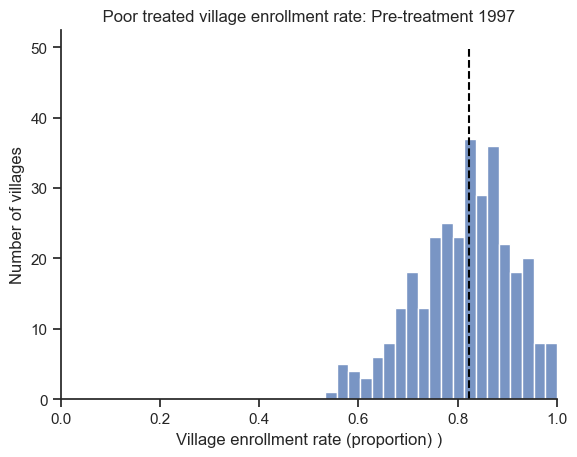

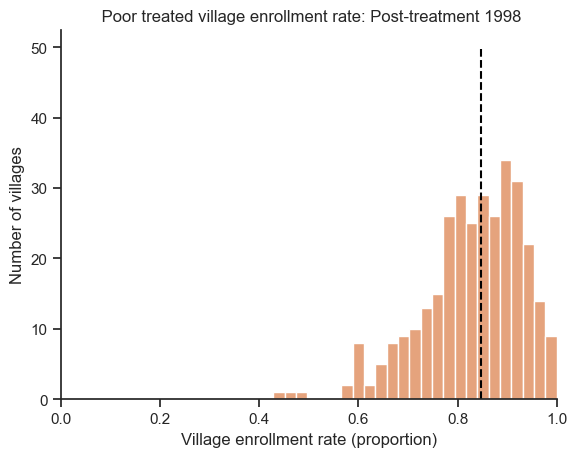

In [287]:
# Generate 2 distributions 
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="ticks", context='notebook')
cmap = sns.color_palette()

# look at poor, enrolled villages only
poor_treated_villages = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 1)]
village_ids_treated = np.unique(poor_treated_villages['village']) # treated village ids

# define pre and post treatement distributions 
pre_treatment_dist = pd.DataFrame(index = village_ids_treated, columns = ['mean_enrollment'])
post_treatment_dist = pd.DataFrame(index = village_ids_treated, columns = ['mean_enrollment'])

# iterate throught villages to get mean enrollment 
for village in village_ids_treated:
    pre_treatment_dist.loc[village,'mean_enrollment'] = poor_treated_villages[(poor_treated_villages['village'] == village) & (poor_treated_villages['year'] == 97)]['sc'].mean()
    post_treatment_dist.loc[village,'mean_enrollment']= poor_treated_villages[(poor_treated_villages['village'] == village) & (poor_treated_villages['year'] == 98)]['sc'].mean()

# make sure its numeric 
pre_treatment_dist = pre_treatment_dist.astype('float64')
post_treatment_dist = post_treatment_dist.astype('float64')

# Plot histograms
xlims = [0,1]
sns.histplot(pre_treatment_dist['mean_enrollment'], bins = 20, color = cmap[0])
mean_pre_treatment = poor_treated_villages[poor_treated_villages['year'] == 97]['sc'].mean() # take mean across households, not across villages 
plt.vlines(mean_pre_treatment, 0, 50, color = 'black', linestyles='dashed')
plt.xlim(xlims)
plt.ylabel('Number of villages')
plt.xlabel('Village enrollment rate (proportion) )')
plt.title(' Poor treated village enrollment rate: Pre-treatment 1997 ')
sns.despine()
plt.show()

sns.histplot(post_treatment_dist['mean_enrollment'], bins = 25, color = cmap[1])
mean_post_treatment = poor_treated_villages[poor_treated_villages['year'] == 98]['sc'].mean() # take mean across households, not across villages 
plt.vlines(mean_post_treatment, 0, 50, color = 'black', linestyles='dashed')
plt.xlim(xlims)
plt.ylabel('Number of villages')
plt.xlabel('Village enrollment rate (proportion)')
plt.title(' Poor treated village enrollment rate: Post-treatment 1998')
sns.despine()
plt.show()


In [301]:
## Part 2: check if difference is significant

# Compute statistic on individual households
pre_treatment_sc = poor_treated_villages[poor_treated_villages['year'] == 97]['sc'].dropna()
post_treatment_sc = poor_treated_villages[poor_treated_villages['year'] == 98]['sc'].dropna()
_, pval_enrollment_treatment_sc = ttest_ind(pre_treatment_sc,post_treatment_sc)
print('Enrollment difference in treatment group (households): ' +  str(pval_enrollment_treatment_sc))

# Compute statistic on villages
_, pval_enrollment_treatment = ttest_ind(post_treatment_dist['mean_enrollment'],pre_treatment_dist['mean_enrollment'])
print('Enrollment difference in treatment group (villages): ' +  str(pval_enrollment_treatment))

Enrollment difference in treatment group (households): 1.2976490728161e-09
Enrollment difference in treatment group (villages): 0.04424870036572114


*Does there appear to be a difference? Is this difference statistically significant?*
- There does appear to be difference in the distribution of mean enrollment across villages in the post vs pre treatment years which can be visually seen by comparing where the dashed line intersects the x-axis in each histogram. 
- When computing a t-test across all households for difference in enrollment in the pre/post period, we obtain a pvalue << 0.01, which suggests that there is a significnat difference in enrollment rates after treatement in the poor villages. 

### 1.5 Graphical exploration, part 2

Repeat the above exercise for poor households in **control villages**, before and after treatment. Do you observe a difference in enrollment in control villages between 1997 and 1998? How does what you observe here affect how you might approach measuring the impact of PROGRESA?

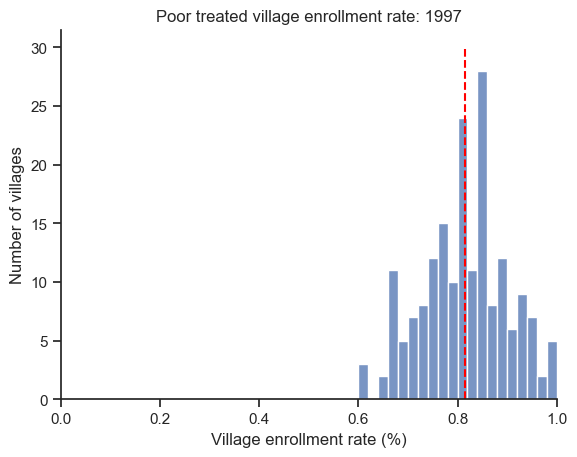

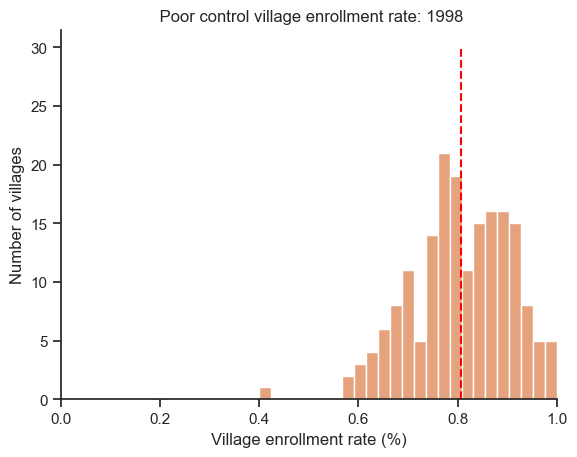

In [288]:
# look at poor, not enrolled villages only
poor_control_villages = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 0)] 
village_ids_ctrl = np.unique(poor_control_villages['village']) # treated villages 

# define pre and post treatement distributions 
pre_treatment_ctrl = pd.DataFrame(index = village_ids_ctrl, columns = ['mean_enrollment'])
post_treatment_ctrl = pd.DataFrame(index = village_ids_ctrl, columns = ['mean_enrollment'])

# iterate throught villages to get mean enrollment 
for village in village_ids_ctrl:
    pre_treatment_ctrl.loc[village,'mean_enrollment'] = poor_control_villages[(poor_control_villages['village'] == village) & (poor_control_villages['year'] == 97)]['sc'].mean()
    post_treatment_ctrl.loc[village,'mean_enrollment']= poor_control_villages[(poor_control_villages['village'] == village) & (poor_control_villages['year'] == 98)]['sc'].mean()

# make sure its numeric 
pre_treatment_ctrl = pre_treatment_ctrl.astype('float64')
post_treatment_ctrl = post_treatment_ctrl.astype('float64')

# Plot histograms
sns.histplot(pre_treatment_ctrl['mean_enrollment'], bins = 20, color = cmap[0])
mean_pre_interv = poor_control_villages[poor_control_villages['year'] == 97]['sc'].mean()# take mean across households, not across villages 
plt.vlines(mean_pre_interv, 0, 30, color = 'red', linestyles='dashed')
plt.xlim(xlims)
plt.ylabel('Number of villages')
plt.xlabel('Village enrollment rate (%)')
plt.title('Poor treated village enrollment rate: 1997')
sns.despine()
plt.show()

sns.histplot(post_treatment_ctrl['mean_enrollment'], bins = 25, color = cmap[1])
mean_post_interv = poor_control_villages[poor_control_villages['year'] == 98]['sc'].mean()# take mean across households, not across villages 
plt.vlines(mean_post_interv, 0, 30, color = 'red', linestyles='dashed')
plt.xlim(xlims)
plt.ylabel('Number of villages')
plt.xlabel('Village enrollment rate (%)')
plt.title(' Poor control village enrollment rate: 1998')
sns.despine()
plt.show()

In [300]:
## Part 2: check if difference is significant

# Compute statistic on individual households
pre_treatment_ctrl_sc = poor_control_villages[poor_control_villages['year'] == 97]['sc'].dropna()
post_treatment_ctrl_sc = poor_control_villages[poor_control_villages['year'] == 98]['sc'].dropna()
_, pval_enrollment_control_sc = ttest_ind(pre_treatment_ctrl_sc,post_treatment_ctrl_sc)
print('Enrollment difference in control group (households): ' +  str(pval_enrollment_control_sc))


# Compute statistic on villages
_, pval_enrollment_control = ttest_ind(pre_treatment_ctrl['mean_enrollment'],post_treatment_ctrl['mean_enrollment'])
print('Enrollment difference in control group (villages): ' +  str(pval_enrollment_control))


Enrollment difference in control group (households): 0.1511345297015608
Enrollment difference in control group (villages): 0.4349129201749543


*Do you observe a difference in enrollment in control villages between 1997 and 1998? How does what you observe here affect how you might approach measuring the impact of PROGRESA?*
- By performing a t-test comparing enrollment for control villages not recieving progressa in 1997 vs 1998, we find that the p_value = 0.151 across households,  which does not meet the criterion value of p = 0.01. Therfore, there is no significant difference in enrollment in the control group between these time points.
- What this reveals is that we may have done proper randomization when assigning control vs treatment since we would expect not to find a difference in enrollment across time if there was no intervention. Therefore, when we explore the effect of progresa on enrollment we may be able to use a simple pre vs post estimator there may not be a counfound of a time trend. 

## Part 2: Measuring Impact

Our goal is to estimate the causal impact of the PROGRESA program on the social and economic outcomes of individuals in Mexico. We will focus on the impact of the program on school enrollment rates among the poor (those with poor=='pobre'), since only the poor were eligible to receive PROGRESA assistance, and since a primary objective of the program was to increase school enrollment.

### 2.1 Simple differences: T-test

Begin by estimating the impact of Progresa using "simple differences." Restricting yourself to data from 1998 (after treatment), calculate the average enrollment rate among **poor** households in the Treatment villages and the average enrollment rate among **poor** households in the control villages. Use a t-test to determine if this difference is statistically significant. What do you conclude?

In [327]:
# Your code here

# get df of enrollment restricted to poor villages with or without treatement in the year 1998
post_ctrl_df = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 0) & (progresa_df['year'] == 98)]
post_treatment_df = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 1) & (progresa_df['year'] == 98)]

# calculate mean enrollment among households 
post_ctrl_mean_enrollment = post_ctrl_df['sc'].mean()
post_trt_mean_enrollment = post_treatment_df['sc'].mean()

# calculate difference: Treatment - Control 
diff = post_trt_mean_enrollment  - post_ctrl_mean_enrollment
print('Simple differences: Treatment - Control in 1998: ' + str(diff))

# perform t-test to determine significance
_, pval_enrollment_diff = ttest_ind(post_ctrl_df['sc'].dropna(), post_treatment_df['sc'].dropna())
print('Simple differences p value : Treatment - Control in 1998: ' + str(pval_enrollment_diff))



Simple differences: Treatment - Control in 1998: 0.0388421646651228
Simple differences p value : Treatment - Control in 1998: 6.636344447523235e-17


*Discuss your results here*
- In this simple treatment vs control estimator we find there is a significant difference between treatment and control groups in 1998 (after progresa intervention). Because of the small magnitude of the p-value, this strongly suggests there is a correlation between treatment intervention and enrollment rate of children. If given proper randomization, the Beta term should be zero and this would be an unbiased estimate. 

### 2.2 Simple differences: Regression

Estimate the effects of Progresa on enrollment using a regression model, by regressing the 1998 enrollment rates **of the poor** on treatment assignment. For now, do not include any other variables in your regression. Discuss the following:

* Based on this model, how much did Progresa increase or decrease the likelihood of a child enrolling? Make sure you express you answer in a sentence that a person with no technical background could understand, using appropriate units.
* How does your regression estimate compare to your t-test estimate from part 2.1?
* Based on this regression model, can we reject the null hypothesis that the treatment effects are zero? 
* What is the counterfactual assumption underlying this regression?

In [436]:
# Your code here
import statsmodels.api as sm

# constrict analysis on poor population and for the year 1998 
regression_df = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['year'] == 98)]
regression_df_simple = regression_df[['progresa','sc']].dropna(axis=0) # only drop nans for individuals with missing data for enrollment or progresa

# assign indepndent and dependent variables
X = sm.add_constant(regression_df_simple['progresa'])
y = regression_df_simple['sc']
ols = sm.OLS(y, X)

# run the regression
ols_result = ols.fit()
ols_result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     sc   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     69.87
Date:                Tue, 06 Feb 2024   Prob (F-statistic):           6.64e-17
Time:                        01:45:14   Log-Likelihood:                -11926.
No. Observations:               27450   AIC:                         2.386e+04
Df Residuals:                   27448   BIC:                         2.387e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8076      0.004    220.676      0.000       0.800       0.815
progresa       0.0388      0.005      8.359      0.000       0.030       0.048
==============================================================================
Omnibus:                     7638.939   Durbin-Watson:                   1.734
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            15767.534
Skew:                          -1.767   Prob(JB):                         0.00
Kurtosis:                       4.140   Cond. No.                         3.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [438]:
print('T-test pvalue:' + str(ols_result.pvalues[1]))

T-test pvalue:6.636344447488953e-17


*Discuss your results here*
1.  Based on this model, how much did Progresa increase or decrease the likelihood of a child enrolling? Make sure you express you answer in a sentence that a person with no technical background could understand, using appropriate units.
- Children that recieved progresa had a 3.9% higher likely-hood of enrolling in school. 
2. How does your regression estimate compare to your t-test estimate from part 2.1?
- By taking a look at the p value based on the t-statistic in the statsmodel summary, we find that the p-value is the same as that computed using a t-test from part 2.1 ->  p_val = 6.63E-17
3. Based on this regression model, can we reject the null hypothesis that the treatment effects are zero? 
- Yes, based on this model since the p_value is < 0.01, we can reject that the treatment effects are zero and that there is a strong correlation between recieving progressa and rate of enrollment. 
4. What is the counterfactual assumption underlying this regression?
- The counterfactual assumption here is that the control group (poor villages that didn't recieve treatment) enrollment rates in 1998 represent the enrollment rates in 1998 that would have occured had the treated group (poor villages that recieved progressa), not actually recieved any intervention. Specifically, the counterfactual assumption is that in the absence of receiving progresa, the villages that received treatment would have experienced similar enrollment rates to those that did not receive progresa. 

### 2.3 Multiple Regression

Estimate the above regression, but this time include a set of control variables. Include, for instance, age, distance to a secondary school, gender, education of household head, welfare index, indigenous, etc.

* How do the controls affect the point estimate of treatment effect?
* How do the controls affect the standard error on the treatment effect? 
* How do you interpret the differences (or similarities) between your estimates of 2.2 and 2.3?
* Interpet the coefficient associated with the `dist_sec` variable. Is this evidence that the household's distance from a secondary school has a *causal* impact on educational attainment?

In [380]:
# Your code here
# define variables of interest from regression_df ( poor population in year 1998)
regression_df_multiple = regression_df[['progresa','dist_sec', 'sex','age', 'sc']].dropna(axis=0) # only drop nans for individuals with missing data for enrollment or progresa

# assign indepndent and dependent variables
X = sm.add_constant(regression_df_multiple[['progresa', 'dist_sec', 'sex', 'age']])
y = regression_df_multiple['sc'].values
ols = sm.OLS(y, X)

# run the regression
ols_multiple_result = ols.fit()
ols_multiple_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     2423.
Date:                Mon, 05 Feb 2024   Prob (F-statistic):               0.00
Time:                        23:23:10   Log-Likelihood:                -7805.5
No. Observations:               27440   AIC:                         1.562e+04
Df Residuals:                   27435   BIC:                         1.566e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5706      0.009    177.798      0.000       1.553       1.588
progresa       0.0357      0.004      8.927      0.000       0.028       0.044
dist_sec      -0.0123      0.001    -14.229      0.000      -0.014      -0.011
sex            0.0307      0.004      7.905      0.000       0.023       0.038
age           -0.0662      0.001    -96.944      0.000      -0.068      -0.065
==============================================================================
Omnibus:                     3068.975   Durbin-Watson:                   1.703
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4208.713
Skew:                          -0.950   Prob(JB):                         0.00
Kurtosis:                       3.267   Cond. No.                         55.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

*Discuss your results here*
1. How do the controls affect the point estimate of treatment effect?
- Considering the control variables age, sex and distance to secondary school; they seem to have little effect on the point estimate of the treatment effect, that being the coefficient for the progresa regressor in this multiple regression (0.0357 MR vs 0.0388 in the SR). 
2. How do the controls affect the standard error on the treatment effect? 
- The controls act to reduce the absolute value of the standard error on the treatment effect. Taking into account the reduction in the point estimate of the treatment effect (ie: comparing the t-statistic), we find that control variables result in a higher t-statistic for progresa and thereby a higher significance of the progresa point estimate. 
3. How do you interpret the differences (or similarities) between your estimates of 2.2 and 2.3?
- There is a high-level of similarity between the progresa estimate from the simple regression results in 2.2 and  multiple regression results in 2.3, suggesting that the treatment effect is robust to the inclusion of additional controls and co-variates. In other words, the treatment effect is unlikely to be biased by confounding factors such as the control variables included. 
4. Interpet the coefficient associated with the `dist_sec` variable. Is this evidence that the household's distance from a secondary school has a *causal* impact on educational attainment?
- The coefficient for dist_sec was significant with small standard errors. The t-statistic had a large magnitude in comparison with the progresa variable, thereby suggesting that there is a large correlation between the enrollment rate of a household and the distance from the nearest secondary school. This makes logical sense when considering the context of the variable as we would expect it to have high predictability on enrollment. Further rigorous estimation such as a difference-in-difference regression is needed to test if this impact is causal. For now the correlation is strong. 

### 2.4 Multiple Regression Revisited

For the same set of control variables that you used in 2.3, carry out the following alternative estimation procedure. 

* First, regress the 1998 enrollment of the poor on the control variables, **without including the treatment assignment.** 
* Second, use this model to obtain predicted values of the 1998 enrollment for each child in the sample used to estimate the model in step 1. 
* Third, compute a new value for each child, which is the difference between the actual 1998 enrollment and the predicted enrollment value from step 2. 
* Finally, regress the difference from step 3 on treatment assignment.

Compare the point estimate and the standard error on treatment assignment that you obtained in step 4 to their analogues in 2.3. Explain the results.

In [415]:
# Your code here

# 1. regress 1998 enrollement on control varliables without treatment assignment  
regression_df_noprogressa = regression_df[['dist_sec', 'sex','age', 'sc']].dropna(axis=0) # only drop nans for individuals with missing data for enrollment or progresa
X = sm.add_constant(regression_df_noprogressa[['dist_sec', 'sex', 'age']])
y = regression_df_noprogressa['sc'].values
ols = sm.OLS(y, X)
ols_noprogressa_result = ols.fit()
ols_noprogressa_result.summary()

# 2. obtain predicted enrollment using above model 
predicted_enrollment = ols_noprogressa_result.params['const'] + ols_noprogressa_result.params['dist_sec']*regression_df_noprogressa['dist_sec'] + ols_noprogressa_result.params['sex']*regression_df_noprogressa['sex'] + ols_noprogressa_result.params['age']*regression_df_noprogressa['age']

# 3. Compute new value: actual enrolment - predicted enrolment 
diff = regression_df_noprogressa['sc'] - predicted_enrollment

# 4. regress difference on treatment assignment 

X = sm.add_constant(regression_df_multiple['progresa'])
y = diff.values
ols = sm.OLS(y, X)
ols_diff_result = ols.fit()
ols_diff_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     79.69
Date:                Tue, 06 Feb 2024   Prob (F-statistic):           4.65e-19
Time:                        00:22:32   Log-Likelihood:                -7805.5
No. Observations:               27440   AIC:                         1.561e+04
Df Residuals:                   27438   BIC:                         1.563e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0222      0.003     -7.031      0.000      -0.028      -0.016
progresa       0.0357      0.004      8.927      0.000       0.028       0.044
==============================================================================
Omnibus:                     3063.571   Durbin-Watson:                   1.703
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4199.137
Skew:                          -0.949   Prob(JB):                         0.00
Kurtosis:                       3.266   Cond. No.                         3.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

*Discuss your results here*
- The point estimate and the standard errors on treatment assingment are the exact same as in 2.3. This makes sense since what we are essentially doing with this estimation procedure is seeing how well the left over difference observed between the actual and predicted enrollment rates from the reduced multiple regression is explained by the treatment assignment when we regress the difference with treatment assignment. Its a good way of checking our understanding of how each regressor is contributing in a multiple regression analysis. 

### 2.5 Difference-in-Difference, version 1 (tabular)

Thus far, we have computed the effects of Progresa by estimating the difference in 1998 enrollment rates across villages. An alternative approach would be to compute the treatment effect using a difference-in-differences framework.

Begin by estimating the average treatment effects of the program for poor households using data from 1997 and 1998. Specifically, calculate the difference (between 1997 and 1998) in enrollment rates among poor households in treated villages; then compute the difference (between 1997 and 1998) in enrollment rates among poor households in control villages. 

Display your results in a 2x2 table where the rows are Control/Treatment and the columns are 1997/1998. 

* What is your difference-in-difference estimate of the impact, and how does it compare to your earlier (simple difference) results?
* What is the counterfactual assumption underlying this estimate? 


In [416]:
# Your code here
# build 2x2 mean enrollment rate table 
diffndiff_table = pd.DataFrame(columns = ['1997', '1998'], index = ['Control', 'Treatment'])
diffndiff_table.loc['Control', '1997'] = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 0) & (progresa_df['year'] == 97)]['sc'].mean()
diffndiff_table.loc['Control', '1998'] = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 0) & (progresa_df['year'] == 98)]['sc'].mean()
diffndiff_table.loc['Treatment', '1997'] = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 1) & (progresa_df['year'] == 97)]['sc'].mean()
diffndiff_table.loc['Treatment', '1998'] = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 1) & (progresa_df['year'] == 98)]['sc'].mean()

#calculate difference and estimator 
diff_treated = diffndiff_table.loc['Treatment', '1998'] - diffndiff_table.loc['Treatment', '1997']
diff_ctrl = diffndiff_table.loc['Control', '1998'] - diffndiff_table.loc['Control', '1997']

diffndiff_estimate = diff_treated - diff_ctrl

# output results
print('Difference-in-difference estimate of the impact: '+ str(diffndiff_estimate))
diffndiff_table.head()

Difference-in-difference estimate of the impact: 0.031331280319323085


,1997,1998
Control,0.815186,0.807637
Treatment,0.822697,0.846479


*Discuss your results here
1. What is your difference-in-difference estimate of the impact, and how does it compare to your earlier (simple difference) results?
- The difference-in-difference estimate of the impact is 0.0313. The earlier simple difference computed in 2.1 was 0.038842. The diff-in-diff estimates is smaller in magnitude since it takes into account any time trend common to control and treatment groups and any permanent differences that may exist between the treatment and control groups. 
 
2. What is the counterfactual assumption underlying this estimate? 
- The counterfactual assumption here is that in the absence of the treatment, the progresa group and the control group would have followed enrollment rates over time. Morevoer the mean outcome difference between the treated and control groups before the treatment represents how they would have continued to differ in the absence of the treatment. This would imply that any change in the outcome after the treatment would be due to the treatment assuming that the former trends assumption holds.

### 2.6 Difference-in-Difference, version 2 (regression)

Now use a regression specification to estimate the average treatment effects of the program in a difference-in-differences, for the poor households. Do this (i) first without including any control variables; and then (ii) do it a second time including at least 5 control variables. 

* What is your estimate (i) of the impact of Progresa? Be very specific in interpreting your coefficients and standard errors, and make sure to specify exactly what units you are measuring and estimating.
* Does your estimate of the impact of Progresa from (i) change when you add control variables as in (ii)? How do you explain these changes, or the lack of changes on the `progresa` coefficient between (i) and (ii)?
* How do the estimates from (i) and (ii) compare to the difference-in-difference estimates from 2.4 above? What accounts for these differences, if any exist?
* What is the counterfactual assumption underlying regression (ii)? 

In [432]:
# Your code here
# a) diff in diff for no control variables 
regression_df = progresa_df[progresa_df['poor'] == 1]
regression_df_simple = regression_df[['progresa','sc', 'year']].dropna(axis=0) # only drop nans for individuals with missing data 

# assign indepndent and dependent variables
regression_df_simple['did'] = regression_df_simple['progresa'] * regression_df_simple['year'] # make new interaction term
X = sm.add_constant(regression_df_simple[['progresa', 'year', 'did']]) # keep year as numeric eg) 97 vs 98 instead of binary 0 = pre-treatment, 1 = post-treatment 
y = regression_df_simple['sc']
ols = sm.OLS(y, X)

# run the regression
ols_result = ols.fit()
ols_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     sc   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     28.31
Date:                Tue, 06 Feb 2024   Prob (F-statistic):           2.76e-18
Time:                        01:01:39   Log-Likelihood:                -26242.
No. Observations:               58372   AIC:                         5.249e+04
Df Residuals:                   58368   BIC:                         5.253e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5474      0.497      3.112      0.002       0.573       2.522
progresa      -3.0316      0.632     -4.800      0.000      -4.270      -1.794
year          -0.0075      0.005     -1.480      0.139      -0.018       0.002
did            0.0313      0.006      4.835      0.000       0.019       0.044
==============================================================================
Omnibus:                    15346.988   Durbin-Watson:                   1.397
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            30608.651
Skew:                          -1.711   Prob(JB):                         0.00
Kurtosis:                       3.937   Cond. No.                     5.72e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.72e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [433]:
# b) diff in diff for no control variables 
regression_df_multiple = regression_df[['progresa','sc', 'year', 'age', 'sex', 'dist_sec', 'welfare_index', 'hohedu']].dropna(axis=0) # only drop nans for individuals with missing data 

# assign indepndent and dependent variables
regression_df_multiple['did'] = regression_df_multiple['progresa'] * regression_df_multiple['year'] # make new interaction term
X = sm.add_constant(regression_df_multiple[['progresa', 'year', 'did', 'age', 'sex', 'dist_sec', 'welfare_index', 'hohedu']]) # keep year as numeric eg) 97 vs 98 instead of binary 0 = pre-treatment, 1 = post-treatment 
y = regression_df_multiple['sc']
ols = sm.OLS(y, X)

# run the regression
ols_result_multiple = ols.fit()
ols_result_multiple.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     sc   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     2754.
Date:                Tue, 06 Feb 2024   Prob (F-statistic):               0.00
Time:                        01:01:39   Log-Likelihood:                -16832.
No. Observations:               58200   AIC:                         3.368e+04
Df Residuals:                   58191   BIC:                         3.376e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.2160      0.426     -2.857      0.004      -2.050      -0.382
progresa         -2.9979      0.539     -5.559      0.000      -4.055      -1.941
year              0.0279      0.004      6.391      0.000       0.019       0.036
did               0.0309      0.006      5.594      0.000       0.020       0.042
age              -0.0654      0.000   -143.157      0.000      -0.066      -0.064
sex               0.0338      0.003     12.598      0.000       0.029       0.039
dist_sec         -0.0102      0.001    -16.502      0.000      -0.011      -0.009
welfare_index  2.382e-05   1.19e-05      2.002      0.045    5.01e-07    4.71e-05
hohedu            0.0076      0.001     14.163      0.000       0.007       0.009
==============================================================================
Omnibus:                     5608.624   Durbin-Watson:                   1.476
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7408.785
Skew:                          -0.872   Prob(JB):                         0.00
Kurtosis:                       3.120   Cond. No.                     3.29e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.29e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

*Discuss your results here*
1. What is your estimate (i) of the impact of Progresa? Be very specific in interpreting your coefficients and standard errors, and make sure to specify exactly what units you are measuring and estimating.
- Based on the estimate in (i), we can say there is a stong impact of progresa on enrollment rates. In this diff-in-diff regresion estimate the "did" coefficient estimates the true effect of the treatment which is 3.3% increased likelihood of enrollment with progresa treatment. The standard error is proporitionally small (0.6%) and the impact is reflected by the magnitude of the t-statistic which is large in magnitude compared to the other regressors. 
2. Does your estimate of the impact of Progresa from (i) change when you add control variables as in (ii)? How do you explain these changes, or the lack of changes on the `progresa` coefficient between (i) and (ii)?
- The impact estimate does change slighlty when adding control variables. The progressa coefficient decreased slightly from i to ii which indicates that the treatment group specific effect that accounts for average
permanent differences between treatment and control group is is not as strong when considering multiple control variables which is a good indication that we are a properly considering sources of biases that will improve the estimation of the treatment. 
3. How do the estimates from (i) and (ii) compare to the difference-in-difference estimates from 2.4 above? What accounts for these differences, if any exist?
- The estimate in (i) is the exact same as the difference-in-difference estimates from 2.4. This is expected given its using the same information (pre/post intervention info for both the control and treatment groups). The estimate in (ii) is slighlty smaller compared to the estimate in 2.4 which is a result of including multiple co-variates (control variables) in the regression. By including control variables in the regression, we address potential sources of bias and improve the precision of the estimated treatment effect. The fact there is very little difference is good since it indicates there is a strong effect due to our intervention and not due to some source of variation in the the control variables. 
4. What is the counterfactual assumption underlying regression (ii)? 
- The counterfactual assumption in the second regression ist that in the absence of the treatment, the treatment group and the control group would have had similar enrollment rates in 1998. Wih the inclusion of control variables in the regression, this counterfactual assumption also extends to the control variables; that is the relationship between the control variables and the enrollment rate would have remained unchanged over time for both the treated and control groups in the absence of the treatment. Essentially, the counterfactual is the relationship would be stable event across control variables. 

### 2.7 Spillover effects

Thus far, we have focused on the impact of PROGRESA on the school enrollment of poor households. Repeat your analysis in 2.5, instead focusing on (a) the impact of PROGRESA on the school enrollment of non-poor households, and (b) the impact ofo PROGRESA on *other outcomes* of poor households that might plausibly have been affected by the PROGRESA program.
* Do you observe any impacts of PROGRESA on the school enrollment of the non-poor?
* Regardless of whether you find evidence of spillovers to non-poor, describe one or two reasons why PROGRESA *might* have impacted non-poor households. Give concrete examples based on the context in which PROGRESA was implemented.
* Do you observe any impacts of PROGRESA on other aspects of the welfare of poor households? 

In [418]:
# Your code here
# a) The impact of progresa on the school enrollment of non-poor households
diffndiff_tablea = pd.DataFrame(columns = ['1997', '1998'], index = ['Control', 'Treatment'])
diffndiff_tablea.loc['Control', '1997'] = progresa_df[(progresa_df['poor'] == 0) & (progresa_df['progresa'] == 0) & (progresa_df['year'] == 97)]['sc'].mean()
diffndiff_tablea.loc['Control', '1998'] = progresa_df[(progresa_df['poor'] == 0) & (progresa_df['progresa'] == 0) & (progresa_df['year'] == 98)]['sc'].mean()
diffndiff_tablea.loc['Treatment', '1997'] = progresa_df[(progresa_df['poor'] == 0) & (progresa_df['progresa'] == 1) & (progresa_df['year'] == 97)]['sc'].mean()
diffndiff_tablea.loc['Treatment', '1998'] = progresa_df[(progresa_df['poor'] == 0) & (progresa_df['progresa'] == 1) & (progresa_df['year'] == 98)]['sc'].mean()

#calculate difference and estimator 
diff_treated_np = diffndiff_tablea.loc['Treatment', '1998'] - diffndiff_tablea.loc['Treatment', '1997']
diff_ctrl_np = diffndiff_tablea.loc['Control', '1998'] - diffndiff_tablea.loc['Control', '1997']

diffndiff_estimate_np = diff_treated_np - diff_ctrl_np

# # output results
print('Difference-in-difference estimate of the impact for non-poor households: '+ str(diffndiff_estimate_np))
diffndiff_tablea.head()

Difference-in-difference estimate of the impact for non-poor households: 3.4275264633842895e-05


,1997,1998
Control,0.762587,0.776337
Treatment,0.795264,0.809049


In [419]:
# b) the impact of PROGRESA on other outcomes of poor households eg) monthly wages of head of household 
diffndiff_tableb = pd.DataFrame(columns = ['1997', '1998'], index = ['Control', 'Treatment'])
diffndiff_tableb.loc['Control', '1997'] = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 0) & (progresa_df['year'] == 97)]['hohwag'].mean()
diffndiff_tableb.loc['Control', '1998'] = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 0) & (progresa_df['year'] == 98)]['hohwag'].mean()
diffndiff_tableb.loc['Treatment', '1997'] = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 1) & (progresa_df['year'] == 97)]['hohwag'].mean()
diffndiff_tableb.loc['Treatment', '1998'] = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 1) & (progresa_df['year'] == 98)]['hohwag'].mean()

#calculate difference and estimator 
diff_treated = diffndiff_tableb.loc['Treatment', '1998'] - diffndiff_tableb.loc['Treatment', '1997']
diff_ctrl = diffndiff_tableb.loc['Control', '1998'] - diffndiff_tableb.loc['Control', '1997']

diffndiff_estimateb = diff_treated - diff_ctrl

# output results
print('Difference-in-difference estimate of the impact on monthly wages: '+ str(diffndiff_estimateb))
diffndiff_tableb.head()

Difference-in-difference estimate of the impact on monthly wages: 0.0


,1997,1998
Control,573.163558,573.163558
Treatment,544.339544,544.339544


In [440]:
# b) the impact of PROGRESA on other outcomes of poor households eg) monthly wages of head of household 
diffndiff_tableb = pd.DataFrame(columns = ['1997', '1998'], index = ['Control', 'Treatment'])
diffndiff_tableb.loc['Control', '1997'] = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 0) & (progresa_df['year'] == 97)]['hohedu'].mean()
diffndiff_tableb.loc['Control', '1998'] = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 0) & (progresa_df['year'] == 98)]['hohedu'].mean()
diffndiff_tableb.loc['Treatment', '1997'] = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 1) & (progresa_df['year'] == 97)]['hohedu'].mean()
diffndiff_tableb.loc['Treatment', '1998'] = progresa_df[(progresa_df['poor'] == 1) & (progresa_df['progresa'] == 1) & (progresa_df['year'] == 98)]['hohedu'].mean()

#calculate difference and estimator 
diff_treatedb = diffndiff_tableb.loc['Treatment', '1998'] - diffndiff_tableb.loc['Treatment', '1997']
diff_ctrlb = diffndiff_tableb.loc['Control', '1998'] - diffndiff_tableb.loc['Control', '1997']

diffndiff_estimateb = diff_treatedb - diff_ctrlb

# output results
print('Difference-in-difference estimate of the impact on head of household education: '+ str(diffndiff_estimateb))
diffndiff_tableb.head()

Difference-in-difference estimate of the impact on head of household education: 0.0


,1997,1998
Control,2.590348,2.590348
Treatment,2.663139,2.663139


1. Do you observe any impacts of PROGRESA on the school enrollment of the non-poor?
- Based on the difference-in-difference estimated performed, there seems to be no impact of progresa on enrollment for non-pool households (dif  = 3.4275264633842895e-05)

2. Regardless of whether you find evidence of spillovers to non-poor, describe one or two reasons why PROGRESA *might* have impacted non-poor households. Give concrete examples based on the context in which PROGRESA was implemented.
- Although from our findings on enrollment there was no spillover effect, progresa may have impacted non-poor households whereby the focus on increasing enrollment of poor households could have resulted in changes in educational infrastrcture such as improvement of libraries and communal learning spaces. These would serve to benefit non-poor households residing in the same area. Moreover, local economic stimulus from progresa injected money could stimualte economic activity and increased job opportunities and community development projects in areas where non-poor children also reside. 

3. Do you observe any impacts of PROGRESA on other aspects of the welfare of poor households? 
- There are limited aspects of welfare in this data set and only at 2 times points (1997 and 1998) so when taking a look at the effects on the head of household education level and at the head of household wages, there was asbolutely no difference in the estimate of the impact of progresa on these since the data seems to be the same. That's not to say there would have been a change over a longer period of time or by looking at other aspects of welfare. 

### 2.8 Summary

* Based on all the analysis you have undertaken to date, do you believe that Progresa had a causal impact on the enrollment rates of poor households in Mexico? 

*Discuss your results here*
- Based on the several analyses we have performed here in this excerise including a difference in difference regression with multiple control variables, we can conclude there is a strong correlation between households that recieved progresa aid and increased enrollment rate in school. This may have a causal impact although further  analyses at later time points following intervention while also considering more related control variables are needed to better assess a causal role. 
- This correlation makes sense since progresa was a conditional cash transfer program whereby households only recieved benefits if they engaged in behaviour to improve family welfare, such as children education and health. One of the limitations of this analysis is that it doesn't consider the fine incentives and disincentives for recieving aid, such as termination of program benefits after a certain point in secondary school which would surely impact the enrollment rates if we broke down our analysis by grade. However overall given the information we have here, it appears progresa had an overall positive impact on poor household school enrollment rates. 